# Turning locomotion controller

This tutorial runs the v2 hybrid turning controller on flat terrain. A two-value descending signal controls left and right CPG amplitude and direction before the hybrid correction rules produce low-level joint and adhesion commands.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from tqdm import trange

from flygym import Simulation
from flygym.anatomy import BodySegment, ContactBodiesPreset
from flygym.compose import FlatGroundWorld
from flygym.examples.locomotion import (
    HybridTurningController,
    LocomotionAction,
    PreprogrammedSteps,
    apply_locomotion_action,
    make_locomotion_fly,
)
from flygym.utils.math import Rotation3D


output_dir = Path("outputs/turning_controller")
output_dir.mkdir(parents=True, exist_ok=True)

In [2]:
fly = make_locomotion_fly(
    name="turning_demo",
    add_adhesion=True,
    colorize=True,
)
body_cam = fly.add_tracking_camera(
    name="body_cam",
    pos_offset=(0.0, -8.0, 1.0),
    rotation=Rotation3D("euler", (1.57, 0.0, 0.0)),
    fovy=35.0,
)

world = FlatGroundWorld()
world.add_fly(
    fly,
    [0, 0, 0.8],
    Rotation3D("quat", [1, 0, 0, 0]),
    bodysegs_with_ground_contact=ContactBodiesPreset.TIBIA_TARSUS_ONLY,
    add_ground_contact_sensors=False,
)

sim = Simulation(world)
renderer = sim.set_renderer(
    [body_cam],
    camera_res=(240, 320),
    playback_speed=0.1,
    output_fps=25,
)

In [3]:
preprogrammed_steps = PreprogrammedSteps()
dof_order = fly.get_actuated_jointdofs_order("position")
controller = HybridTurningController(
    timestep=sim.timestep,
    preprogrammed_steps=preprogrammed_steps,
    output_dof_order=dof_order,
)

print("Actuated DoFs:", len(dof_order))
print("Simulation timestep:", sim.timestep)

Actuated DoFs: 42
Simulation timestep: 0.0001


In [4]:
sim.reset()
controller.reset(seed=0)

initial_action = LocomotionAction(
    joint_angles=preprogrammed_steps.default_pose_by_dof_order(dof_order),
    adhesion_onoff=np.ones(6, dtype=bool),
)
apply_locomotion_action(sim, fly.name, initial_action)
sim.warmup()

In [5]:
run_time = 0.6
nsteps_sim = int(run_time / sim.timestep)
time_grid = np.arange(nsteps_sim) * sim.timestep

thorax_idx = fly.get_bodysegs_order().index(BodySegment("c_thorax"))
thorax_positions = np.full((nsteps_sim, 3), np.nan, dtype=np.float32)
cpg_magnitudes = np.full((nsteps_sim, 6), np.nan, dtype=np.float32)
descending_signals = np.full((nsteps_sim, 2), np.nan, dtype=np.float32)

for step_idx in trange(nsteps_sim, desc="Running turning controller"):
    curr_time = step_idx * sim.timestep
    if curr_time < run_time / 2:
        descending_signal = np.array([1.2, 0.4])
    else:
        descending_signal = np.array([0.4, 1.2])

    action = controller.step(descending_signal, sim, fly.name)
    apply_locomotion_action(sim, fly.name, action)
    sim.step_with_profile()

    thorax_positions[step_idx] = sim.get_body_positions(fly.name)[thorax_idx]
    cpg_magnitudes[step_idx] = controller.cpg_network.curr_magnitudes
    descending_signals[step_idx] = descending_signal

    sim.render_as_needed_with_profile()

print("Rendered frames:", len(renderer.frames[body_cam.full_identifier]))
print(
    "Final thorax displacement:",
    np.round(thorax_positions[-1] - thorax_positions[0], 3),
    "mm",
)
sim.print_performance_report()

Running turning controller: 100%|██████████| 5999/5999 [00:10<00:00, 585.45it/s]

Rendered frames: 147
Final thorax displacement: [ 5.409 -1.818 -0.158] mm
PERFORMANCE PROFILE


Stage,Time/step (us),Percent (%),Throughput (iters/s),Throughput x realtime
Physics simulation advancement,93,8,10770,1.08
Rendering*,1105,92,905,0.09
TOTAL,1198,100,835,0.08


* Note: 147 frames were rendered out of 5999 steps. Therefore, rendering time per image is 45091 us.


In [6]:
sim.renderer.show_in_notebook()
sim.renderer.save_video(output_dir / "hybrid_turning_controller.mp4")

turning_demo/body_cam This browser does not support the video tag.


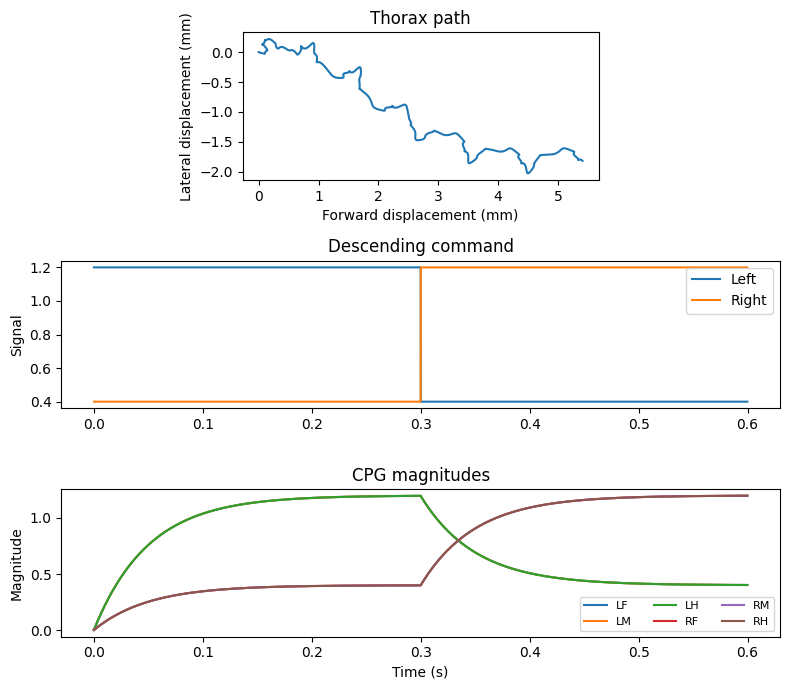

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(8, 7), tight_layout=True)

axes[0].plot(
    thorax_positions[:, 0] - thorax_positions[0, 0],
    thorax_positions[:, 1] - thorax_positions[0, 1],
)
axes[0].set_aspect("equal", adjustable="box")
axes[0].set_xlabel("Forward displacement (mm)")
axes[0].set_ylabel("Lateral displacement (mm)")
axes[0].set_title("Thorax path")

axes[1].plot(time_grid, descending_signals[:, 0], label="Left")
axes[1].plot(time_grid, descending_signals[:, 1], label="Right")
axes[1].set_ylabel("Signal")
axes[1].set_title("Descending command")
axes[1].legend()

for leg_idx, leg in enumerate(preprogrammed_steps.legs):
    axes[2].plot(time_grid, cpg_magnitudes[:, leg_idx], label=leg.upper())
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("Magnitude")
axes[2].set_title("CPG magnitudes")
axes[2].legend(ncols=3, fontsize=8)

fig.savefig(output_dir / "turning_controller_diagnostics.png")